In [1]:
import csv
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

CSV_PATH = "./data/human_measurement.csv"
SAVE_FIGS = False

def _parse_row(raw: str) -> tuple[float, int] | None:
    """Extract (time, min_swaps) from one raw CSV line, skipping header/malformed rows."""
    raw = raw.strip()
    if not raw or raw.lower().startswith("time"):
        return None
    # take only what comes before the first quoted group field
    # format: time,swaps,"true_groups","pred_groups"
    m = re.match(r'^([0-9.]+),([0-9]+),', raw)
    if not m:
        return None
    try:
        return float(m.group(1)), int(m.group(2))
    except ValueError:
        return None

records: list[dict] = []
with open(CSV_PATH, newline="", encoding="utf-8") as f:
    raw_content = f.read()

# Split on newlines but keep quoted content intact via csv reader on cleaned lines
for line in raw_content.splitlines():
    result = _parse_row(line)
    if result:
        t, swaps = result
        records.append({"time": t, "min_swaps": swaps})

times   = np.array([r["time"]      for r in records])
swaps   = np.array([r["min_swaps"] for r in records])
indices = np.arange(1, len(records) + 1)

print(f"Loaded {len(records)} puzzle attempts")
print(f"Zero-one accuracy (perfect solves): {(swaps == 0).mean():.1%}")
print(f"Mean min-swaps:  {swaps.mean():.2f}  |  Median: {np.median(swaps):.1f}")
print(f"Mean time:       {times.mean():.1f}s  |  Median: {np.median(times):.1f}s")

Loaded 28 puzzle attempts
Zero-one accuracy (perfect solves): 35.7%
Mean min-swaps:  1.14  |  Median: 1.0
Mean time:       114.5s  |  Median: 96.0s


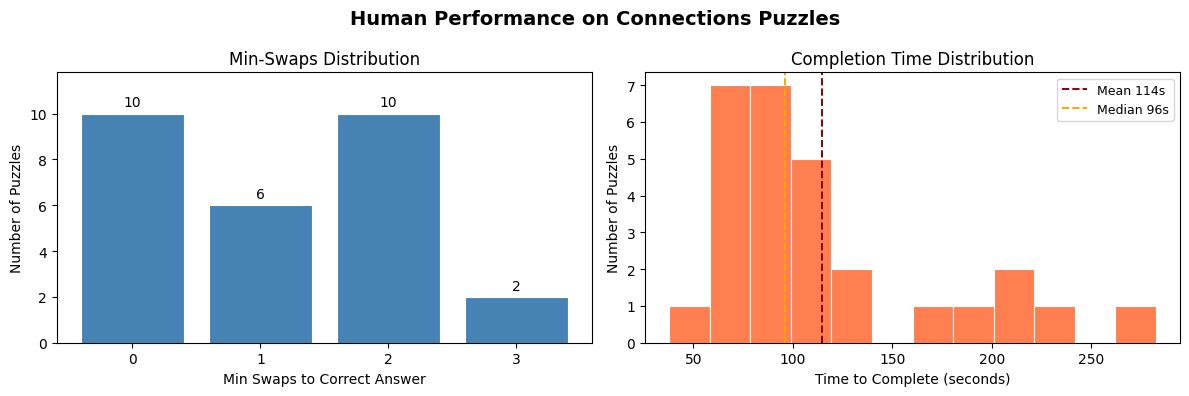

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Human Performance on Connections Puzzles", fontsize=14, fontweight="bold")

# --- Min-swaps distribution ---
ax = axes[0]
unique, counts = np.unique(swaps, return_counts=True)
bars = ax.bar(unique, counts, color="steelblue", edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Min Swaps to Correct Answer")
ax.set_ylabel("Number of Puzzles")
ax.set_title("Min-Swaps Distribution")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, counts.max() * 1.18)

# --- Time distribution ---
ax2 = axes[1]
ax2.hist(times, bins=12, color="coral", edgecolor="white", linewidth=0.8)
ax2.axvline(times.mean(), color="darkred", linestyle="--", linewidth=1.4, label=f"Mean {times.mean():.0f}s")
ax2.axvline(np.median(times), color="orange", linestyle="--", linewidth=1.4, label=f"Median {np.median(times):.0f}s")
ax2.set_xlabel("Time to Complete (seconds)")
ax2.set_ylabel("Number of Puzzles")
ax2.set_title("Completion Time Distribution")
ax2.legend(fontsize=9)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("./data/human_performance_overview.png", dpi=150, bbox_inches="tight")
plt.show()

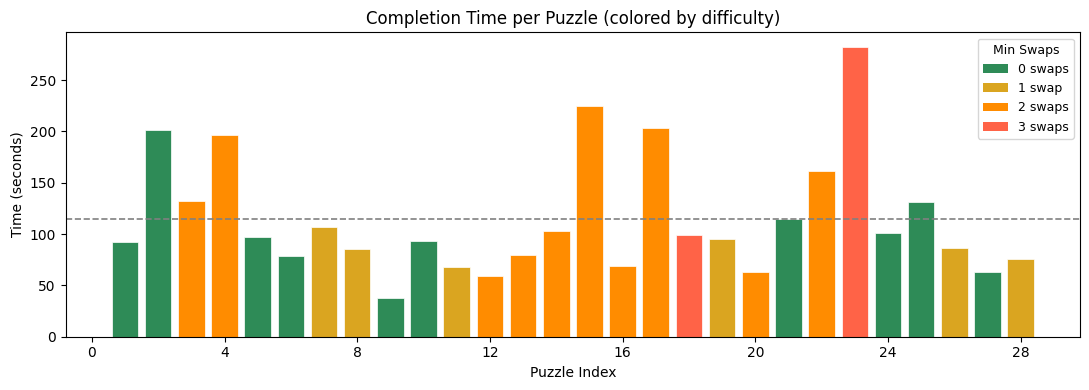

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))

colors = {0: "seagreen", 1: "goldenrod", 2: "darkorange", 3: "tomato"}
bar_colors = [colors.get(s, "grey") for s in swaps]

ax.bar(indices, times, color=bar_colors, edgecolor="white", linewidth=0.5)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors[k], label=f"{k} swap{'s' if k != 1 else ''}") for k in sorted(colors)]
ax.legend(handles=legend_handles, title="Min Swaps", fontsize=9, title_fontsize=9, loc="upper right")

ax.axhline(times.mean(), color="grey", linestyle="--", linewidth=1.2, label=f"Mean {times.mean():.0f}s")
ax.set_xlabel("Puzzle Index")
ax.set_ylabel("Time (seconds)")
ax.set_title("Completion Time per Puzzle (colored by difficulty)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("./data/human_performance_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

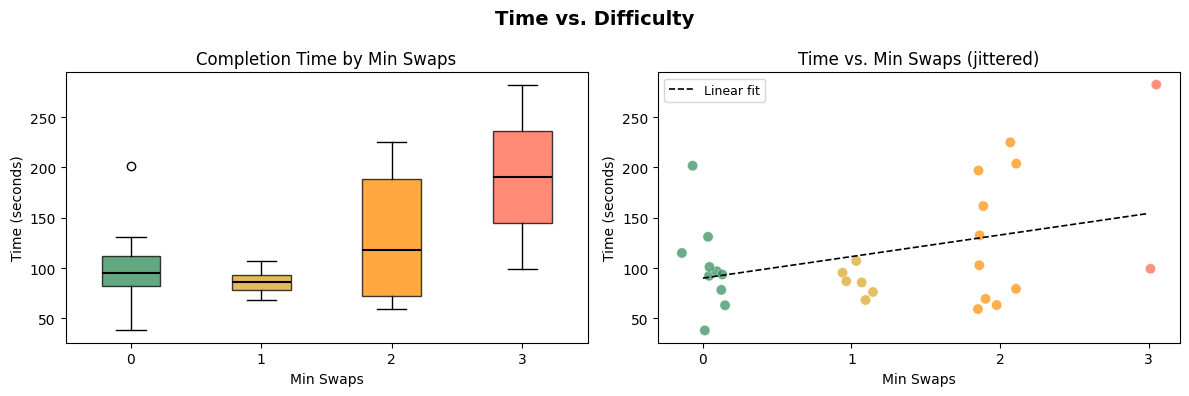

Pearson r (min_swaps vs time): 0.371


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Time vs. Difficulty", fontsize=14, fontweight="bold")

swap_labels = sorted(np.unique(swaps))
swap_groups = [times[swaps == s] for s in swap_labels]

# --- Box plot: time by swap count ---
ax = axes[0]
bp = ax.boxplot(swap_groups, patch_artist=True, medianprops=dict(color="black", linewidth=1.5))
box_colors = ["seagreen", "goldenrod", "darkorange", "tomato", "purple"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticklabels([str(s) for s in swap_labels])
ax.set_xlabel("Min Swaps")
ax.set_ylabel("Time (seconds)")
ax.set_title("Completion Time by Min Swaps")

# --- Scatter: time vs swaps with jitter ---
ax2 = axes[1]
jitter = np.random.default_rng(0).uniform(-0.15, 0.15, size=len(swaps))
scatter_colors = [box_colors[int(s)] for s in swaps]
ax2.scatter(swaps + jitter, times, c=scatter_colors, alpha=0.7, edgecolors="white", linewidths=0.4, s=55)
# trend line
z = np.polyfit(swaps, times, 1)
x_line = np.linspace(swaps.min(), swaps.max(), 100)
ax2.plot(x_line, np.poly1d(z)(x_line), color="black", linestyle="--", linewidth=1.2, label="Linear fit")
ax2.set_xlabel("Min Swaps")
ax2.set_ylabel("Time (seconds)")
ax2.set_title("Time vs. Min Swaps (jittered)")
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.legend(fontsize=9)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("./data/human_time_vs_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()

corr = np.corrcoef(swaps, times)[0, 1]
print(f"Pearson r (min_swaps vs time): {corr:.3f}")

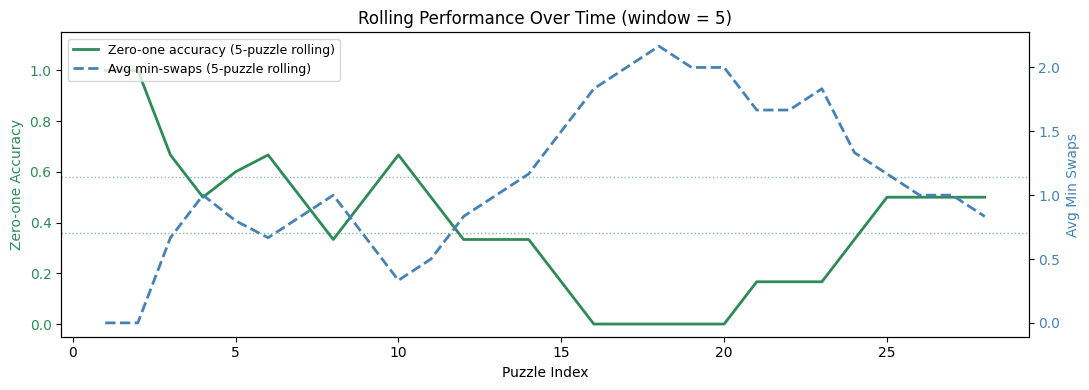

In [5]:
WINDOW = 5

rolling_zo  = [float((swaps[max(0, i-WINDOW):i+1] == 0).mean()) for i in range(len(swaps))]
rolling_avg = [float(swaps[max(0, i-WINDOW):i+1].mean()) for i in range(len(swaps))]

fig, ax = plt.subplots(figsize=(11, 4))
ax2 = ax.twinx()

ax.plot(indices, rolling_zo,  color="seagreen", linewidth=2,   label=f"Zero-one accuracy ({WINDOW}-puzzle rolling)")
ax2.plot(indices, rolling_avg, color="steelblue", linewidth=2, linestyle="--", label=f"Avg min-swaps ({WINDOW}-puzzle rolling)")

ax.axhline(float((swaps == 0).mean()), color="seagreen", linestyle=":", linewidth=1, alpha=0.6)
ax2.axhline(float(swaps.mean()), color="steelblue", linestyle=":", linewidth=1, alpha=0.6)

ax.set_xlabel("Puzzle Index")
ax.set_ylabel("Zero-one Accuracy", color="seagreen")
ax2.set_ylabel("Avg Min Swaps", color="steelblue")
ax.set_title(f"Rolling Performance Over Time (window = {WINDOW})")
ax.set_ylim(-0.05, 1.15)
ax.tick_params(axis="y", labelcolor="seagreen")
ax2.tick_params(axis="y", labelcolor="steelblue")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig("./data/human_rolling_performance.png", dpi=150, bbox_inches="tight")
plt.show()